In [3]:
# Import
import numpy as np
import pandas as pd
import re
import xarray as xr
import matplotlib.pyplot as plt
import datetime, os
from cartopy import crs as ccrs
from cartopy import feature as cfeature

New logbooks stats:

In [4]:
#read in both cleaned datasats - tier 1 and 4
base_dir = '~/Documents/whaling_logs/'

#subtract all IDs from june export to get rows added in last 6 mo
export_6 = pd.read_csv(os.path.join(base_dir, '20250606_export/logentries-export-2025-06-11.csv'), low_memory=False)
export_10 = pd.read_csv(os.path.join(base_dir, '20260211_export/csv_files/logentries-export-2026-02-11.csv'), low_memory=False)

# Get IDs present in June export
ids_june = set(export_6["ID"])

# Keep only rows in October that are NOT in June
new_rows = export_10[~export_10["ID"].isin(ids_june)].copy()

print(f"New rows added since June: {len(new_rows):,}")

New rows added since June: 22,929


In [5]:
#Now what are these logbooks
unique_logbooks = new_rows["LogBook ID"].dropna().unique().tolist()

print(f"Number of new logbooks: {len(unique_logbooks)}")
unique_logbooks

Number of new logbooks: 42


['Alaska (Bark) 1880-1884',
 'Alexander Barclay (Ship) 1837-…',
 'Alto (Bark) 1857-1862',
 'Amazon (1856-1860)',
 'Amethyst (Ship) 1838-1840',
 'Barnstable (Bark) 1860-1864',
 'Canton (ship) 1862-1866',
 'Charles W. Morgan (Ship) 1841-…',
 'Chili (Ship) 1848-1852',
 'Congress (Ship) 1857-1859',
 'Cora (Bark) 1839-1841',
 'Elisha Dunbar (Bark) 1854-1858',
 'Emeline (Schooner) 1843-1844',
 'Emerald (Ship) 1835-1837',
 'Falcon (Bark) 1865-1867',
 'Fenelon (Ship) 1840-1842',
 'Francis Allyn (Schooner) 1891-…',
 'Governor Hopkins (Brig) 1839-1…',
 'Harbinger (Ship)  1842-1844',
 'Herald (Ship)  1834-1837',
 'Hibernia (Ship) 1842-1844',
 'Jason (Ship)  1846-1848',
 'Jasper (Bark) 1840-1842',
 'Jasper (ship) 1839-1841',
 'Lapwing (Ship) 1860-1863',
 'Mercator(Ship) 1840-1843',
 'Milo (ship) 1849-1851',
 'Napoleon (bark) 1868-1872',
 'Neptune (Ship) 1837-1839',
 'Oscar (Bark) 1836-1838',
 'Pioneer (Bark) 1858-1861',
 'President (Bark) 1865-1869',
 'Richmond (Bark) 1851-1853',
 'Rodman (Bark) 1

In [14]:
#feb export
df_10_tier1 = pd.read_csv(os.path.join(base_dir, '20260211_export/csv_files/Tier1.csv'), low_memory=False)
df_10_tier4 = pd.read_csv(os.path.join(base_dir, '20260211_export/csv_files/Tier4.csv'), low_memory=False)

#July export
df_7_tier1 = pd.read_pickle(os.path.join(base_dir, '20250728_export/PKL/Tier1.pkl'))
df_7_tier4 = pd.read_pickle(os.path.join(base_dir, '20250728_export/PKL/Final_tier4_2025-08-26.pkl'))

In [15]:
new_entries_1 = df_10_tier1[df_10_tier1["LogBook ID"].isin(unique_logbooks)]
new_entries_4 = df_10_tier4[df_10_tier4["LogBook ID"].isin(unique_logbooks)]

#Lets confirm we are only missing ones still udnergoing review
# All logbooks present in the dataset
present_logbooks = set(df_10_tier1["LogBook ID"].dropna().unique())
# Logbooks we added since june but not in cleaned ds
missing_logbooks = set(unique_logbooks) - present_logbooks
missing_logbooks

{'Alaska (Bark) 1880-1884',
 'Barnstable (Bark) 1860-1864',
 'Congress (Ship) 1857-1859',
 'Herald (Ship)  1834-1837',
 'Jason (Ship)  1846-1848',
 'Lapwing (Ship) 1860-1863',
 'Mercator(Ship) 1840-1843',
 'President (Bark) 1865-1869',
 'Scotland (Bark) 1857-1860',
 'TEST TEST HG JULY 2025',
 'Westward-1978'}

In [16]:
meta_df = pd.read_csv(os.path.join(base_dir, '20251021_export/csv_files/logbooks-export-meta.csv'), low_memory=False)
meta_df[meta_df['Researcher'] == 'Stephen Luce']

,ID,Log Book,LogBook ID,Repository,Repository Call Number,Sherman Ref Code,Researcher,Vessel,Home Port,Flag,Master,Home Meridian,Service Type,Met Instruments
3,19423,Abigail (ship) 1847-1850,Abigail (ship) 1847-1850,Providence Public Library,Wh A148 1847j,65,Stephen Luce,Abigail,"New Bedford, MA",USA,George E. Young,"Greenwich, UK",Whaler,NaN
15,31500,Albion (Ship) 1829-1830,Albion (Ship) 1829-1830,Providence Public Library,WH A337 1829L,169,Stephen Luce,Albion,"Fairhaven, MA",USA,Sheffel Read,"Greenwich, UK",Whaler,NaN
33,27846,Arbella (Ship) 1830-1831,Arbella (Ship) 1830-1831,Providence Public Library,Wh A6583 1830L,406,Stephen Luce,Arbella,"Plymouth, MA",USA,George Harris,"Greenwich, UK",Whaler,NaN
43,45890,Benjamin Rush (ship) 1833-1835,Benjamin Rush (ship) 1833-1835,Providence Public Library,Wh B468 1833L,606,Stephen Luce,Benjamin rush,"Warren, RI",USA,James Coffin,"Greenwich, UK",Whaler,NaN
51,64816,Brunswick (ship) 1834-1837,Brunswick (ship) 1834-1837,Providence Public Library,Wh B899 1834L,713/714,Stephen Luce,Brunswick,"Providence, R.I.",USA,Heman N. Stuart (Stewart in whalinghistory.org),"Greenwick, UK",Whaler,chronometer
55,56534,Cadmus (ship) 1834-1837,Cadmus (ship) 1834-1837,Providence Public Library,Wh C124 1834L,729,Stephen Luce,Cadmus,"Fair Haven, MA",USA,William Crowell,"Greenwich, UK",Whaler,NaN
63,48176,Charles and Henry (ship) 1833-1836,Charles and Henry (ship) 1833-1836,Providence Public Library,Wh C4756 1833L,911,Stephen Luce,Charles and Henry,"Nantucket, MA",USA,George F. Joy,"Greenwich, UK",Whaler,NaN
71,16972,Clarice (Bark) 1846-1849,Clarice (Bark) 1846-1849,Providence Public Library,Wh C5915 1846J,1086,Stephen Luce,Clarice,"New Bedford, MA",USA,Peleg W. Gifford,"Greenwich, UK",Whaler,NaN
79,118283,Cora (Bark) 1839-1841,Cora (Bark) 1839-1841,Providence Public library,Wh C787 1839L,1221,Stephen Luce,Cora,New Bedford,USA,Humphrey Shearman,"Greenwich, UK",Whaler,NaN
81,54489,Courier (ship) 1834-1836,Courier (ship) 1834-1836,Providence Public Library,Wh C859 1834L,1281,Stephen Luce,Courier,"Dorchester, MA",USA,Wilmot Luce,"Greenwich, UK",Whaler,NaN


In [17]:
logbook_name_map = {
    'Francis Allyn (Schooner) 1891-…': 'Francis Allyn (Schooner) 1891-1893',
    'Governor Hopkins (Brig) 1839-1…': 'Governor Hopkins (Brig) 1839-1840'
}

new_entries_fixed_1 = new_entries_1.copy()
# Replace only IDs found in mapping; keep all others unchanged
new_entries_fixed_1["LogBook ID"] = (
    new_entries_fixed_1["LogBook ID"]
    .map(logbook_name_map)
    .fillna(new_entries_fixed_1["LogBook ID"])
)

new_entries_fixed_4 = new_entries_4.copy()
new_entries_fixed_4["LogBook ID"] = (
    new_entries_fixed_4["LogBook ID"]
    .map(logbook_name_map)
    .fillna(new_entries_fixed_4["LogBook ID"])
)

In [18]:
# count number of new entries per logbook
entry_counts = (
    new_entries_fixed_1
    .groupby("LogBook ID")
    .size()
    .reset_index(name="# of entries")
)

#get logbook metadata
meta_subset = (
    meta_df[["LogBook ID", "Researcher", "Repository"]]
    .drop_duplicates()
)

# merge into df
summary = entry_counts.merge(
    meta_subset,
    on="LogBook ID",
    how="left"
)

In [19]:
summary

,LogBook ID,# of entries,Researcher,Repository
0,Alexander Barclay (Ship) 1837-…,440,NaN,NaN
1,Alto (Bark) 1857-1862,709,David Miller,Falmouth Museum on the Green
2,Amazon (1856-1860),902,Maverick O'Neil-Butters,NBWM
3,Amethyst (Ship) 1838-1840,607,Prashantha Lakshmi Thakkallapally,NBWM
4,Canton (ship) 1862-1866,691,Len Travers,New Bedford Whaling Museum
5,Charles W. Morgan (Ship) 1841-…,95,NaN,NaN
6,Chili (Ship) 1848-1852,24,NaN,NaN
7,Cora (Bark) 1839-1841,734,Stephen Luce,Providence Public library
8,Elisha Dunbar (Bark) 1854-1858,1229,Jessica Desrosiers,New Bedford Whaling Museum
9,Emeline (Schooner) 1843-1844,317,Kavinaya Rameshkumar Bhuvana,New Bedford Whaling Museum


In [10]:
#summary.to_csv("csv_files/new_logbooks_overview.csv", index=False)

Making plots:

we have added 10611 entries over the last 6 months


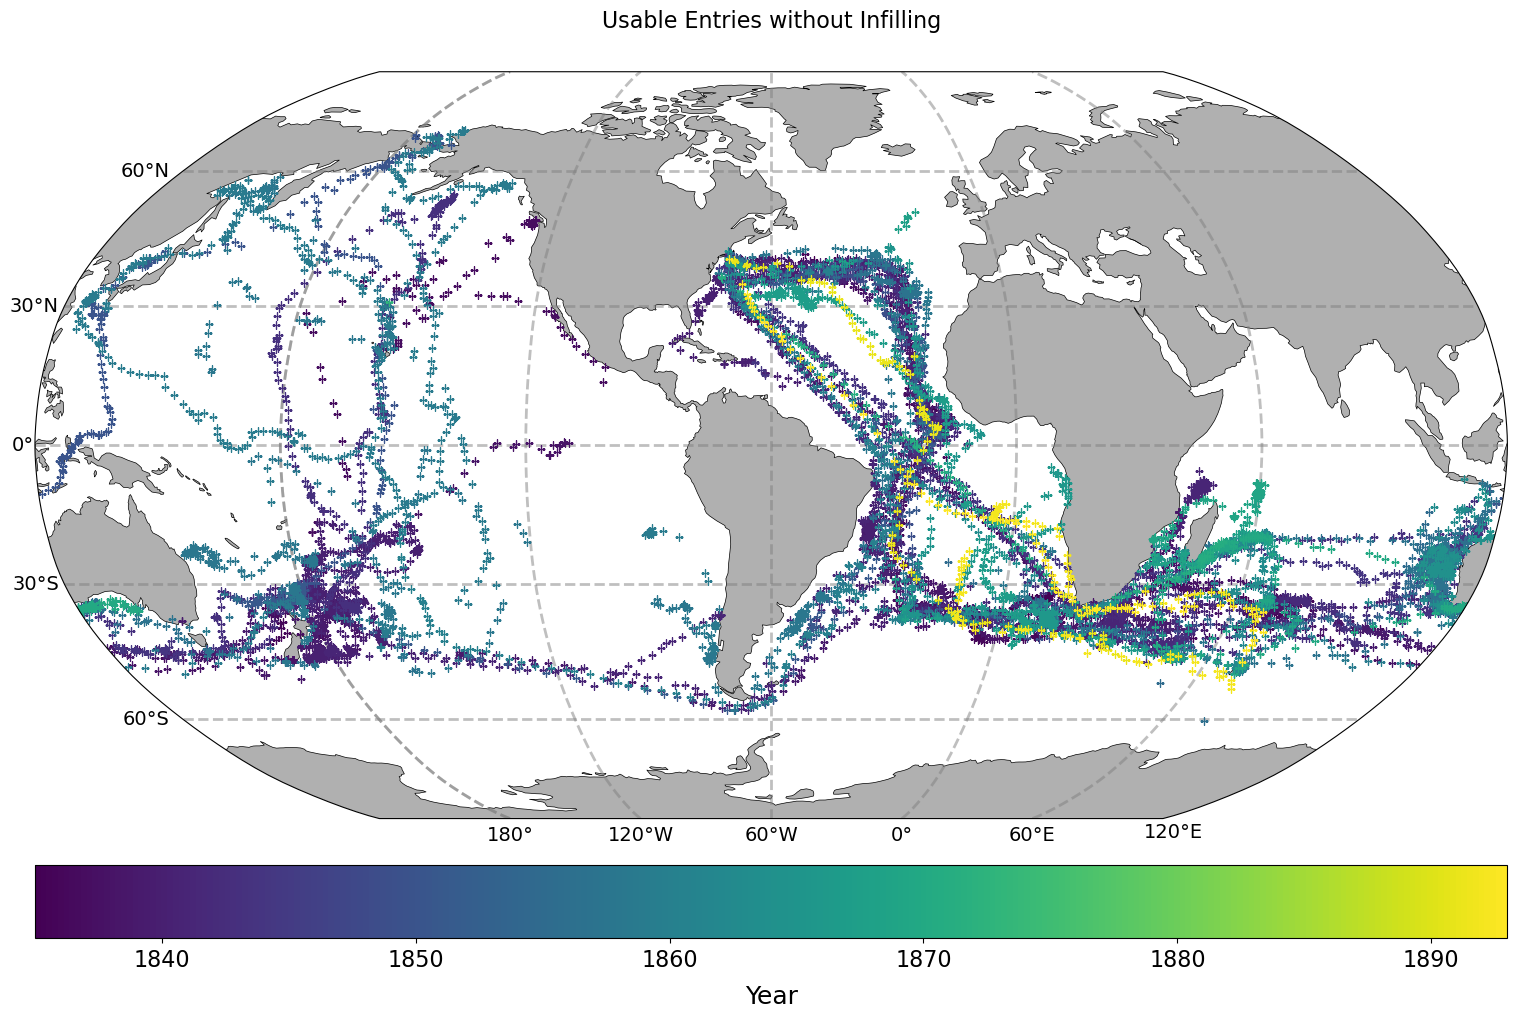

In [20]:
from utils.s_plots import plot_global

df_1 = new_entries_fixed_1.copy()

df_1['Entry Date Time'] = pd.to_datetime(df_1['Entry Date Time'])

df_coords = df_1[df_1["Latitude_decimal"].notna() & df_1["Longitude_decimal"].notna()]
df_usable = df_coords[df_coords["BF Value"].notna()]

print(f'we have added {len(df_usable)} entries over the last 6 months')

out_path = 'newsletter_figures'
filename = 'new_usable_entries.png'
plot_global(df_coords, df_usable, out_dir = out_path, fname = filename, start_year=1820, end_year=1900, save = True)

In [12]:
from utils.stats import summarize_voyages

df = new_entries_fixed_1.copy()
summary_df = summarize_voyages(df)

top_time = summary_df.nlargest(5, 'Duration (days)')
top_time

,LogBook ID,Start Date,End Date,Duration (days),Distance (km)
4,Elisha Dunbar (Bark) 1854-1858,1854-11-14 12:00:00,1955-12-13 12:00:00,36918,108054.471
17,Sea Breeze (1865 - 1871),1865-10-18 12:00:00,1870-02-28 12:00:00,1594,0.000
1,Amazon (1856-1860),1856-10-22 12:00:00,1860-06-07 12:00:00,1324,149710.272
15,Rodman (Bark) 1855-1859,1855-09-11 12:00:00,1859-01-24 12:00:00,1231,100789.653
18,Young Phenix (1867 -1871),1868-01-01 12:00:00,1871-04-21 12:00:00,1206,98922.065


In [13]:
top_distance = summary_df.nlargest(5, 'Distance (km)')
top_distance

,LogBook ID,Start Date,End Date,Duration (days),Distance (km)
1,Amazon (1856-1860),1856-10-22 12:00:00,1860-06-07 12:00:00,1324,149710.272
4,Elisha Dunbar (Bark) 1854-1858,1854-11-14 12:00:00,1955-12-13 12:00:00,36918,108054.471
15,Rodman (Bark) 1855-1859,1855-09-11 12:00:00,1859-01-24 12:00:00,1231,100789.653
18,Young Phenix (1867 -1871),1868-01-01 12:00:00,1871-04-21 12:00:00,1206,98922.065
3,Cora (Bark) 1839-1841,1839-05-10 12:00:00,1841-05-12 12:00:00,733,90944.367


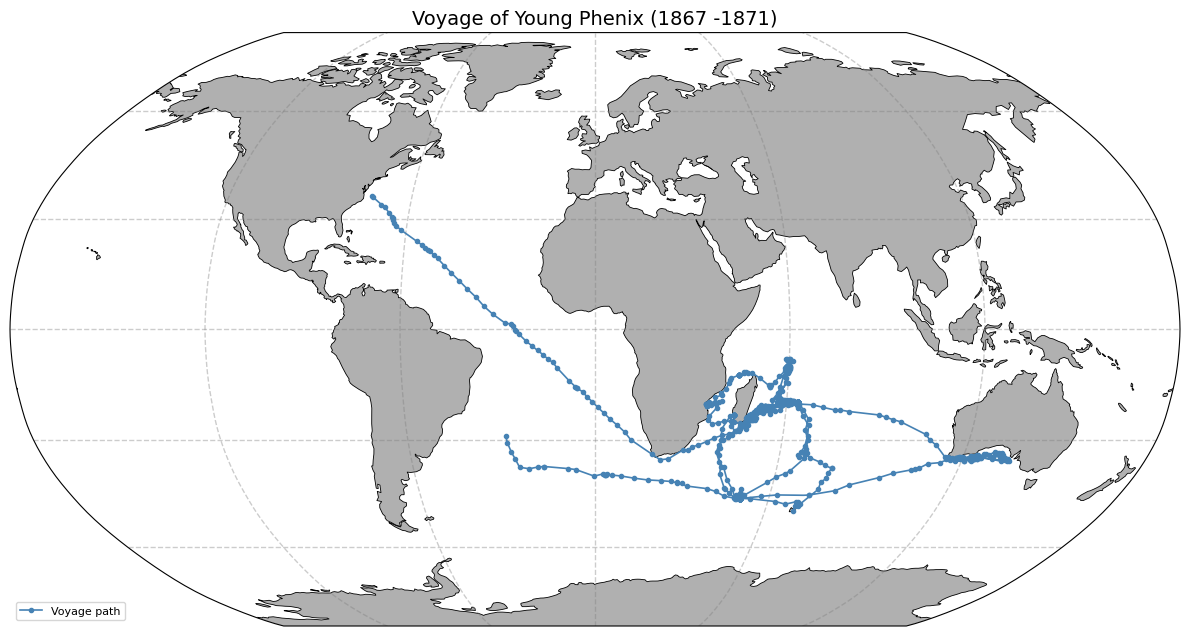

(<Figure size 1200x800 with 1 Axes>,
 <GeoAxes: title={'center': 'Voyage of Young Phenix (1867 -1871)'}>)

In [17]:
from utils.x_plots import plot_single_journey

plot_single_journey(df, 'Young Phenix (1867 -1871)', save = True, title = 'Voyage of Young Phenix (1867 -1871)')

In [28]:
southernmost_rows = new_entries_fixed_4.nsmallest(10, 'Latitude_decimal')

print(
    southernmost_rows[
        ['ID', 'LogBook ID', 'DateTime', 'Latitude', 'Latitude_decimal', 
         'Longitude', 'Longitude_decimal']
    ]
)

            ID               LogBook ID             DateTime Latitude  \
100759  118808  Rodman (Bark) 1855-1859  1856-01-10 12:00:00  61 10 S   
100755  118804  Rodman (Bark) 1855-1859  1856-01-06 12:00:00  61 06 S   
100752  118801  Rodman (Bark) 1855-1859  1856-01-03 12:00:00  60 36 S   
100761  118898  Rodman (Bark) 1855-1859  1856-01-12 12:00:00  60 20 S   
100756  118805  Rodman (Bark) 1855-1859  1856-01-07 12:00:00  59 53 S   
100757  118806  Rodman (Bark) 1855-1859  1856-01-08 12:00:00  59 38 S   
100750  118799  Rodman (Bark) 1855-1859  1856-01-01 12:00:00  59 06 S   
100762  118899  Rodman (Bark) 1855-1859  1856-01-13 12:00:00  58 05 S   
100749  118798  Rodman (Bark) 1855-1859  1855-12-31 12:00:00  57 59 S   
8287    109332    Alto (Bark) 1857-1862  1858-06-17 12:00:00  57 48 S   

        Latitude_decimal Longitude  Longitude_decimal  
100759        -61.166667       NaN                NaN  
100755        -61.100000       NaN                NaN  
100752        -60.600000    

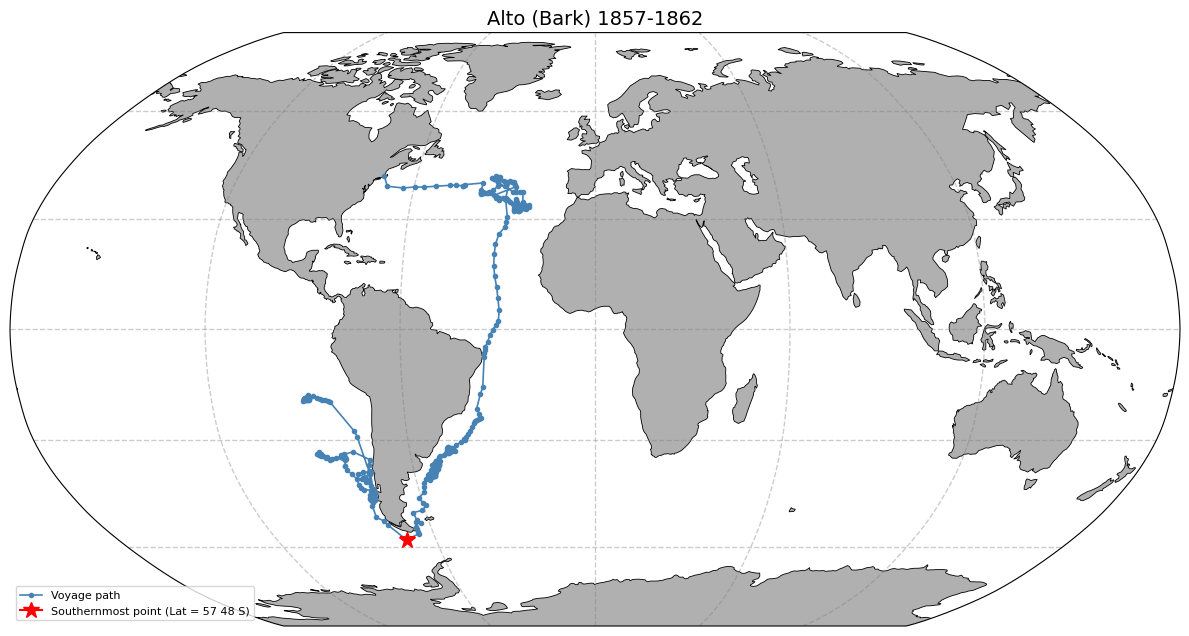

(<Figure size 1200x800 with 1 Axes>,
 <GeoAxes: title={'center': 'Alto (Bark) 1857-1862'}>)

In [30]:
plot_single_journey(new_entries_fixed_4, 'Alto (Bark) 1857-1862', save = True, southernmost = True, title = 'Alto (Bark) 1857-1862')

In [ ]:
windiest_rows = df_4_trimmed.nlargest(3, 'BF Value')

print(
    windiest_rows[
        ['ID', 'LogBook ID', 'DateTime', 'Latitude', 'Longitude', 'BF Value']
    ]
)

In [ ]:
pd.set_option('display.max_columns', None)
df_4_trimmed[df_4_trimmed['ID']==130258]

In [ ]:
plot_single_journey(df_4_trimmed, 'Jasper (ship) 1839-1841', save = False, southernmost_id= 130258, title = 'Jasper (ship) 1839-1841')